This project aims to develop a machine learning system that recommends the most suitable crop to grow and predicts crop yield based on environmental factors, including weather, rainfall, and climate.

#### Import libraries

In [223]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix

from sklearn.neighbors import KNeighborsClassifier
from sklearn.feature_selection import SequentialFeatureSelector
from sklearn.inspection import permutation_importance

from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.metrics import geometric_mean_score


#### Load datasets

In [159]:
df_soil = pd.read_csv('../data/texas.csv')
df_weather = pd.read_csv('../data/texas_weather_2025.csv')

In [160]:
df_soil.head()

,areasymbol,musym,muname,compname,saverest,taxorder,drainagecl,elev_r,slope_r,hzdept_r,hzdepb_r,ph1to1h2o_r,om_r,ec_r,cec7_r,awc_r,cropname,yldunits,nonirryield_r,irryield_r
0,TX129,SfD,"Springer fine sandy loam, 5 to 8 percent slopes",Springer,9/4/2025 7:20:13 PM,Alfisols,Well drained,610.0,7.0,0,41,7.0,0.5,1.0,11.7,0.10,Alfalfa hay,Tons,3.0,6.0
1,TX129,SfD,"Springer fine sandy loam, 5 to 8 percent slopes",Springer,9/4/2025 7:20:13 PM,Alfisols,Well drained,610.0,7.0,0,41,7.0,0.5,1.0,11.7,0.10,Cotton lint,Lbs,225.0,600.0
2,TX129,SfD,"Springer fine sandy loam, 5 to 8 percent slopes",Springer,9/4/2025 7:20:13 PM,Alfisols,Well drained,610.0,7.0,0,41,7.0,0.5,1.0,11.7,0.10,Grain sorghum,Bu,25.0,75.0
3,TX129,AlA,"Altus fine sandy loam, dry, 0 to 1 percent slopes",Altus,9/4/2025 7:20:13 PM,Mollisols,Well drained,662.9,0.5,0,25,6.6,1.5,0.0,9.8,0.13,Grain sorghum,Bu,50.0,NaN
4,TX129,AlA,"Altus fine sandy loam, dry, 0 to 1 percent slopes",Altus,9/4/2025 7:20:13 PM,Mollisols,Well drained,662.9,0.5,0,25,6.6,1.5,0.0,9.8,0.13,Improved bermudagrass,AUM,6.0,NaN


In [161]:
df_soil.columns

Index(['areasymbol', 'musym', 'muname', 'compname', 'saverest', 'taxorder',
       'drainagecl', 'elev_r', 'slope_r', 'hzdept_r', 'hzdepb_r',
       'ph1to1h2o_r', 'om_r', 'ec_r', 'cec7_r', 'awc_r', 'cropname',
       'yldunits', 'nonirryield_r', 'irryield_r'],
      dtype='str')

#### Features
* We drop areasymbol because the is identification of the area. That does not have meaning itself.
* We drop musym and muname because taxorder indicates the soil type more briefly than those. They are too specifi to use.
* We drop saverest because this is updated data and all are updated in Sepetember in 2025.
* We drop hzdept because all values in this column is 0.

| Column | Description | Usage |
| --- | --- | --- |
| areasymbol | A unique code that identifies a specific soil survey area | Drop |
| musym | A short unique identifier used to label a specific map unit within a single soil survey area | Drop |
| muname | The full, formal name of the soil unit | Drop |
| compname | Name of soil component, very specific than taxorder | Feature |
| saverest | Time stamp represent the exact date and time of soil data | Drop |
| taxorder | The highest level in Soil Taxonomy or Soil type| Feature |
| drainagecl | Drainage class | Feature |
| elev_r | Altitude or elevation | Feature |
| slope_r | Slope | Feature |
| hzdept_r | The distance from the top of the soil surface to the upper boundary of a specific soil horizon | Drop |
| hzdepb_r | The distance from the top of the soil surface to the lower boundary of a specific soil horizon | Feature |
| ph1to1h2o_r | pH | Feature |
| om_r | Nutrient | Feature |
| ec_r | EC (electrical Conductivity) | Feature |
| cec7_r | CEC (Cation Exchange Capacity) | Feature
| awc_r | AWC (Available Water Capacity) | Feature
| cropname | The name of crops | Target for crop recommendation |
| yldunits | Crop yield units per unit area for the specified crop | Use when standardizeing the crop yield |
| nonirryield_r | The expected yield per acre of the specific crop without irrigation | Target for crop yield prediction |
| irryield_r | The expected yield per acre of the specific crop with irrigation | Target for crop yield prediction |


https://docs.google.com/document/d/1hZgvWIYF03py2quTsW1hpOCYE-pO2eVkZ7HLiCrpQ7E/edit?tab=t.0

In [162]:
df_soil = df_soil.drop(
    ['areasymbol', 
    'musym', 
    'muname', 
    'saverest',
    'hzdept_r', 
    'nonirryield_r', 
    'irryield_r'], 
    axis=1
    )

In [163]:
df_soil = df_soil.drop('compname', axis=1)

In [164]:
df_soil.columns

Index(['taxorder', 'drainagecl', 'elev_r', 'slope_r', 'hzdepb_r',
       'ph1to1h2o_r', 'om_r', 'ec_r', 'cec7_r', 'awc_r', 'cropname',
       'yldunits'],
      dtype='str')

In [165]:
df_soil.head()

,taxorder,drainagecl,elev_r,slope_r,hzdepb_r,ph1to1h2o_r,om_r,ec_r,cec7_r,awc_r,cropname,yldunits
0,Alfisols,Well drained,610.0,7.0,41,7.0,0.5,1.0,11.7,0.10,Alfalfa hay,Tons
1,Alfisols,Well drained,610.0,7.0,41,7.0,0.5,1.0,11.7,0.10,Cotton lint,Lbs
2,Alfisols,Well drained,610.0,7.0,41,7.0,0.5,1.0,11.7,0.10,Grain sorghum,Bu
3,Mollisols,Well drained,662.9,0.5,25,6.6,1.5,0.0,9.8,0.13,Grain sorghum,Bu
4,Mollisols,Well drained,662.9,0.5,25,6.6,1.5,0.0,9.8,0.13,Improved bermudagrass,AUM


#### Explore the dataset

In [166]:
print(df_soil.shape)
print(df_soil.info())
print(df_soil.describe())

(49146, 12)
<class 'pandas.DataFrame'>
RangeIndex: 49146 entries, 0 to 49145
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   taxorder     48222 non-null  str    
 1   drainagecl   48499 non-null  str    
 2   elev_r       49112 non-null  float64
 3   slope_r      49146 non-null  float64
 4   hzdepb_r     49146 non-null  int64  
 5   ph1to1h2o_r  48413 non-null  float64
 6   om_r         48349 non-null  float64
 7   ec_r         48415 non-null  float64
 8   cec7_r       44311 non-null  float64
 9   awc_r        48412 non-null  float64
 10  cropname     45004 non-null  str    
 11  yldunits     44999 non-null  str    
dtypes: float64(7), int64(1), str(4)
memory usage: 4.5 MB
None
             elev_r      slope_r      hzdepb_r   ph1to1h2o_r          om_r  \
count  49112.000000  49146.00000  49146.000000  48413.000000  48349.000000   
mean     385.182768      2.78738     28.752961      7.019268      1.629065   
std  

#### Missing values

In [167]:
# Count missing values
print(df_soil.isnull().sum())

taxorder        924
drainagecl      647
elev_r           34
slope_r           0
hzdepb_r          0
ph1to1h2o_r     733
om_r            797
ec_r            731
cec7_r         4835
awc_r           734
cropname       4142
yldunits       4147
dtype: int64


In [168]:
# Drop null values in cropname (target variable)
df_soil = df_soil.dropna(subset=['cropname'])

# Count missing values
print(df_soil.isnull().sum())
print(df_soil.shape)

taxorder          2
drainagecl        0
elev_r            0
slope_r           0
hzdepb_r          0
ph1to1h2o_r      11
om_r             11
ec_r              9
cec7_r         3864
awc_r            11
cropname          0
yldunits          5
dtype: int64
(45004, 12)


#### Number of unique values

In [169]:
# Number of unique values
df_soil.nunique()

taxorder         7
drainagecl       7
elev_r         782
slope_r         52
hzdepb_r       110
ph1to1h2o_r     46
om_r           112
ec_r            36
cec7_r         355
awc_r           25
cropname        49
yldunits         7
dtype: int64

# --- For prediction ---

#### Stadardize crop yield

In [170]:
df_soil['yldunits'].unique()

<StringArray>
['Tons', 'Lbs', 'Bu', 'AUM', 'Sacks', 'Boxes', nan, 'Crates']
Length: 8, dtype: str

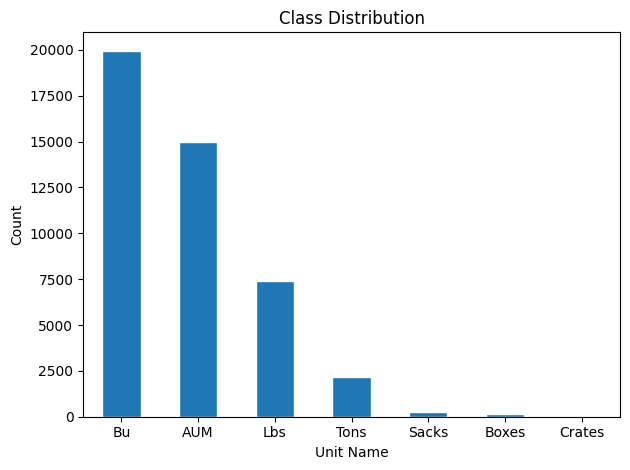

In [171]:
df_soil['yldunits'].value_counts().plot(
    kind='bar',
    edgecolor='white', 
    width=0.5
)

plt.xticks(rotation=0)
plt.title('Class Distribution', fontsize=12)
plt.xlabel('Unit Name')
plt.ylabel('Count')


plt.tight_layout()
plt.show()

* Weight (Tons, Lbs)
* Volume (Bu, Sacks, Boxes, Crates)
* Carrying capacity (AUM)

Since units measure different things, we cannot standardize all of them across the category. For example we cannot convert Boxes to Lbs because a "Box" of oranges doesn't weigh the same as a "Box" of strawberries. 

https://www.grainunitconverter.com/\
In USDA, a sack is almost equivalent to CWT
We arbitrarily set the conversion rate.
Standardize Lbs
| Crop | Unit | Lb |
| --- | --- | --- |
| Anything | 1 US ton | 2000 lbs |
| Grain sorghum | 1 Bu | 56 lbs |
| Corn | 1 Bu | 56 lbs |
| Wheat/Winter wheat | 1 Bu | 60 lbs |
| Oats | 1 Bu | 34 lbs |
| Peaches | 1 Bu | 48 lbs?|
| Soybeans | 1 Bu | 60 lbs |
| Green peas | 1 Bu | 60 lbs |
| Flax | 1 Bu | 56 lbs |
| Rye | 1 Bu | 56 lbs |
| Rice | 1 Bu | 45 lbs? |
| Barley | 1 Bu | 48 lbs |
| Carrots | 1 Bu | 50 lbs? |
| Onions | 1 sack | 100 lbs? |
| Grapefruit | 1 box | 85 lbs? |
| Oranges | 1 box | 90 lbs? |
| Cantaloupe | 1 crate | 80 lbs? |
| Cabbage | 1 crate | 50 lbs? |
| Anything | 1 AUM | 800 lbs? |






In [172]:
weight = df_soil[df_soil['yldunits'].isin(['Tons', 'Lbs'])]['cropname'].unique()
volume = df_soil[df_soil['yldunits'].isin(['Bu', 'Sacks', 'Boxes', 'Crates'])]['cropname'].unique()
capacity = df_soil[df_soil['yldunits'] == 'AUM']['cropname'].unique()

print(weight)
print(volume)
print(capacity)

<StringArray>
[     'Alfalfa hay',      'Cotton lint',    'Grain sorghum',
      'Watermelons',        'Sugarcane',          'Peanuts',
      'Sorghum hay',           'Alfafa',      'Corn silage',
       'Sunflowers',   'Sorghum silage', 'Small grains hay',
        'Grass hay',         'Dry peas',          'Spinach',
       'Legume hay', 'Pima cotton lint']
Length: 17, dtype: str
<StringArray>
['Grain sorghum',         'Wheat',          'Corn',  'Winter wheat',
        'Onions',    'Grapefruit',       'Oranges',          'Oats',
       'Peaches',      'Soybeans',    'Green peas',          'Flax',
           'Rye',          'Rice',        'Barley',       'Carrots',
    'Cantaloupe',       'Cabbage']
Length: 18, dtype: str
<StringArray>
['Improved bermudagrass',     'Weeping lovegrass',          'Buffel grass',
            'Kleingrass',            'Bahiagrass',   'Common bermudagrass',
    'Caucasian bluestem',   'Introduced bluestem', 'Small grains grazeout',
        'Sorghum grazed',  

In [173]:
df_soil = df_soil.drop('yldunits', axis=1)

# ---------------------------------------------

#### Class distribution

In [174]:
# Count of each class
print("Class counts:")
print(df_soil['cropname'].value_counts())

Class counts:
cropname
Improved bermudagrass    7684
Grain sorghum            7427
Cotton lint              5745
Wheat                    5083
Corn                     3704
Common bermudagrass      2386
Oats                     1997
Bahiagrass               1860
Alfalfa hay              1193
Peanuts                  1150
Soybeans                  968
Small grains grazeout     920
Weeping lovegrass         643
Introduced bluestem       476
Rice                      412
Kleingrass                395
Watermelons               381
Tall fescue               298
Corn silage               275
Onions                    271
Peaches                   189
Green peas                167
Sorghum grazed            165
Winter wheat              154
Barley                    151
Carrots                   101
Sorghum silage             99
Sorghum hay                91
Grapefruit                 79
Oranges                    79
Buffel grass               78
Caucasian bluestem         75
Sugarcane        

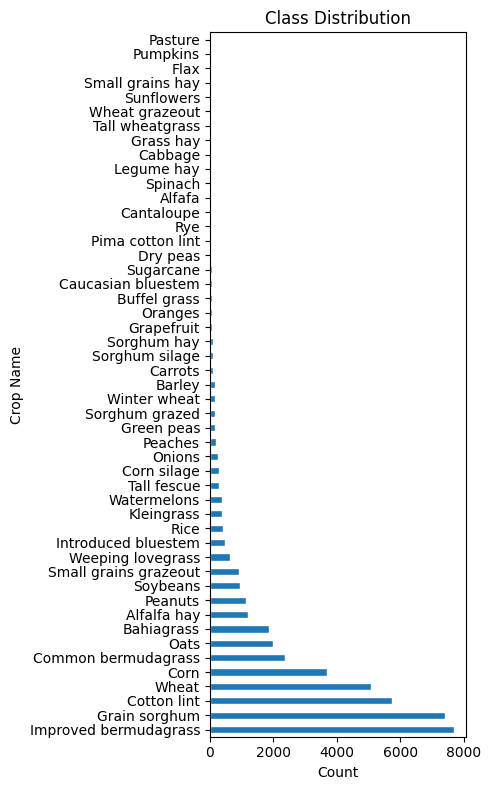

In [175]:
plt.figure(figsize=(5, 8))

# Change 'kind' to 'barh' for horizontal bars
df_soil['cropname'].value_counts().plot(
    kind='barh',
    edgecolor='white', 
    width=0.5
)

# Swap labels to match the new orientation
plt.title('Class Distribution', fontsize=12)
plt.xlabel('Count')       # Now the x-axis shows the count
plt.ylabel('Crop Name')   # Now the y-axis shows the crop names

plt.tight_layout()
plt.show()

#### Map cropname to crop category

In [176]:
# Define the mapping dictionary
crop_mapping = {
    # Cereal Grains
    'Corn': 'Cereal Grains', 'Grain sorghum': 'Cereal Grains', 'Wheat': 'Cereal Grains', 
    'Winter wheat': 'Cereal Grains', 'Oats': 'Cereal Grains', 'Rice': 'Cereal Grains', 
    'Barley': 'Cereal Grains', 'Rye': 'Cereal Grains',
    # Pasture Grasses
    'Improved bermudagrass': 'Pasture Grasses', 'Common bermudagrass': 'Pasture Grasses', 
    'Bahiagrass': 'Pasture Grasses', 'Weeping lovegrass': 'Pasture Grasses', 
    'Introduced bluestem': 'Pasture Grasses', 'Kleingrass': 'Pasture Grasses', 
    'Tall fescue': 'Pasture Grasses', 'Buffel grass': 'Pasture Grasses', 
    'Caucasian bluestem': 'Pasture Grasses', 'Tall wheatgrass': 'Pasture Grasses', 
    'Pasture': 'Pasture Grasses',
    # Hay & Forage
    'Alfalfa hay': 'Hay & Forage', 'Alfafa': 'Hay & Forage', 'Sorghum hay': 'Hay & Forage', 
    'Legume hay': 'Hay & Forage', 'Grass hay': 'Hay & Forage', 'Small grains hay': 'Hay & Forage',
    # Silage & Grazing
    'Corn silage': 'Silage & Grazing', 'Small grains grazeout': 'Silage & Grazing', 
    'Sorghum grazed': 'Silage & Grazing', 'Sorghum silage': 'Silage & Grazing', 
    'Wheat grazeout': 'Silage & Grazing',
    # Fiber Crops
    'Cotton lint': 'Fiber Crops', 'Pima cotton lint': 'Fiber Crops', 'Flax': 'Fiber Crops',
    # Oilseeds & Legumes
    'Peanuts': 'Oilseeds & Legumes', 'Soybeans': 'Oilseeds & Legumes', 
    'Green peas': 'Oilseeds & Legumes', 'Dry peas': 'Oilseeds & Legumes', 
    'Sunflowers': 'Oilseeds & Legumes',
    # Vegetables & Melons
    'Onions': 'Vegetables & Melons', 'Watermelons': 'Vegetables & Melons', 
    'Carrots': 'Vegetables & Melons', 'Spinach': 'Vegetables & Melons', 
    'Cabbage': 'Vegetables & Melons', 'Cantaloupe': 'Vegetables & Melons', 
    'Pumpkins': 'Vegetables & Melons',
    # Fruits
    'Peaches': 'Fruits', 'Grapefruit': 'Fruits', 'Oranges': 'Fruits',
    # Specialty
    'Sugarcane': 'Specialty Crops'
}

# Apply mapping to your dataframe
df_soil['crop_category'] = df_soil['cropname'].map(crop_mapping)
df_soil = df_soil.drop('cropname', axis=1)
print(df_soil['crop_category'].nunique())

9


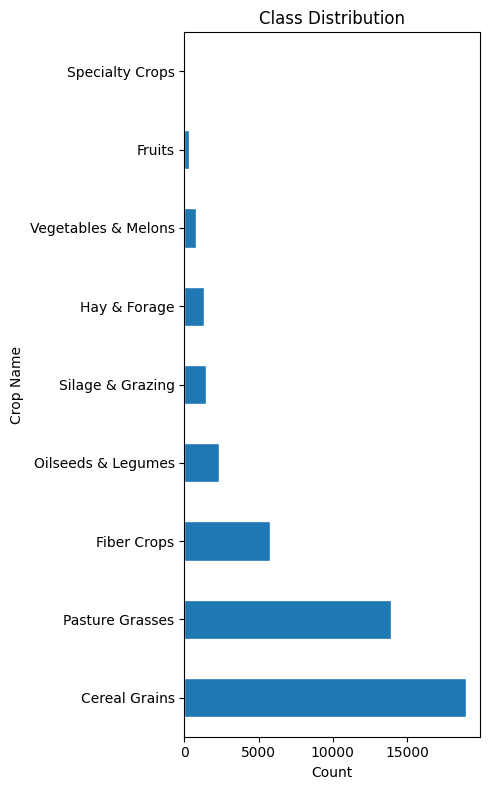

In [177]:
plt.figure(figsize=(5, 8))

# Change 'kind' to 'barh' for horizontal bars
df_soil['crop_category'].value_counts().plot(
    kind='barh',
    edgecolor='white', 
    width=0.5
)

# Swap labels to match the new orientation
plt.title('Class Distribution', fontsize=12)
plt.xlabel('Count')       # Now the x-axis shows the count
plt.ylabel('Crop Name')   # Now the y-axis shows the crop names

plt.tight_layout()
plt.show()

#### Correlation matrix

In [178]:
# Select numeric colmns
num_cols = df_soil.select_dtypes(include=['int64', 'float64']).columns
print("Numeric features:", num_cols.tolist())

# Select categorical columns
cat_cols = df_soil.select_dtypes(include=['str', 'object']).columns
print("Categorical features:", cat_cols.tolist())

Numeric features: ['elev_r', 'slope_r', 'hzdepb_r', 'ph1to1h2o_r', 'om_r', 'ec_r', 'cec7_r', 'awc_r']
Categorical features: ['taxorder', 'drainagecl', 'crop_category']


In [179]:
# Make a correlation matrix
cm = df_soil[num_cols].corr()
print(cm)

               elev_r   slope_r  hzdepb_r  ph1to1h2o_r      om_r      ec_r  \
elev_r       1.000000 -0.068378 -0.061533     0.457961 -0.002216  0.083472   
slope_r     -0.068378  1.000000 -0.094847    -0.089381 -0.184970 -0.110577   
hzdepb_r    -0.061533 -0.094847  1.000000     0.141671 -0.004805  0.038575   
ph1to1h2o_r  0.457961 -0.089381  0.141671     1.000000  0.277338  0.199649   
om_r        -0.002216 -0.184970 -0.004805     0.277338  1.000000  0.057878   
ec_r         0.083472 -0.110577  0.038575     0.199649  0.057878  1.000000   
cec7_r      -0.024700 -0.128459  0.039625     0.458300  0.645033  0.161309   
awc_r        0.092748 -0.177678 -0.074996     0.298228  0.384092  0.013640   

               cec7_r     awc_r  
elev_r      -0.024700  0.092748  
slope_r     -0.128459 -0.177678  
hzdepb_r     0.039625 -0.074996  
ph1to1h2o_r  0.458300  0.298228  
om_r         0.645033  0.384092  
ec_r         0.161309  0.013640  
cec7_r       1.000000  0.387066  
awc_r        0.387066  1.

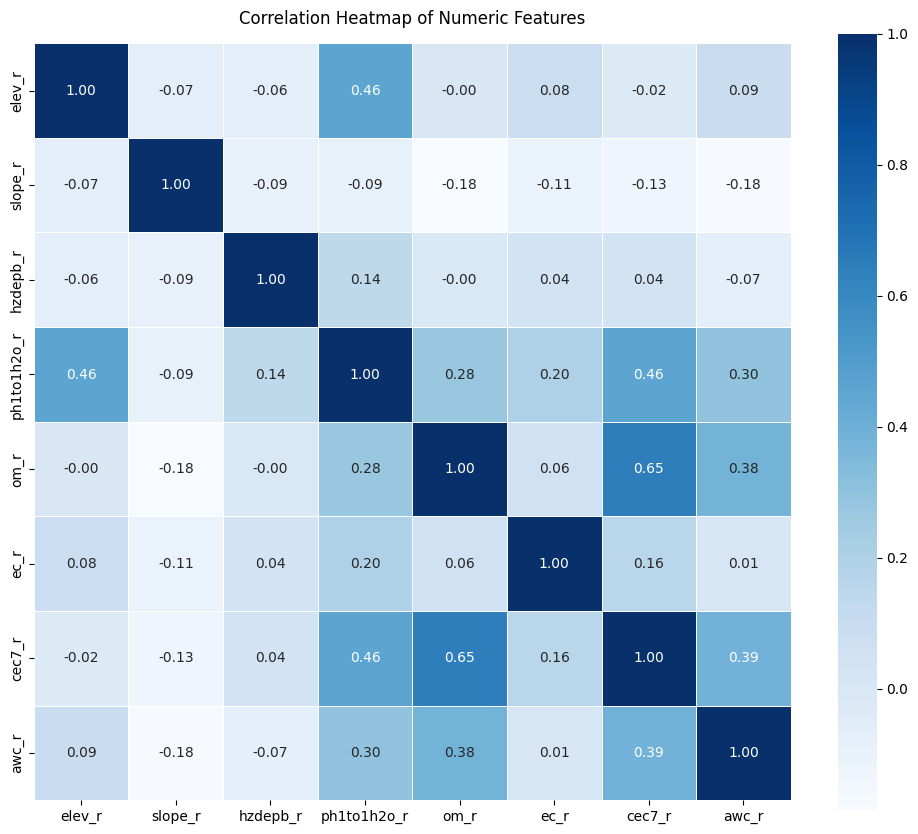

In [180]:
fig, ax = plt.subplots(figsize=(10, 10))
sns.heatmap(
    cm,
    annot=True,
    fmt='.2f',
    cmap='Blues',
    linewidths=0.5,
    ax=ax,
    square=True,
    cbar_kws={'shrink': 0.8}
)
ax.set_title('Correlation Heatmap of Numeric Features', fontsize=12, pad=14)
plt.tight_layout()
plt.show()

### Train and test split

In [214]:
X = df_soil.drop('crop_category', axis=1)
y = df_soil['crop_category']

X_train, X_test, y_train, y_test = train_test_split(
    X, 
    y, 
    test_size=0.2, 
    random_state=42
)

In [215]:
num_cols = X.select_dtypes(include=['int64', 'float64']).columns
cat_cols = X.select_dtypes(include=['str', 'object']).columns
print(num_cols)
print(cat_cols)

Index(['elev_r', 'slope_r', 'hzdepb_r', 'ph1to1h2o_r', 'om_r', 'ec_r',
       'cec7_r', 'awc_r'],
      dtype='str')
Index(['taxorder', 'drainagecl'], dtype='str')


#### Random Forest pipeline

In [224]:
num_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler())

])

cat_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot',  OneHotEncoder(
                    drop='first',
                    handle_unknown='ignore',
                    sparse_output=False))
])

preprocessor = ColumnTransformer(transformers=[
    ('num', num_pipeline, num_cols),
    ('cat', cat_pipeline, cat_cols)
])

rf_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('rf', RandomForestClassifier(class_weight='balanced', random_state=42))
])


In [ ]:
rf_pipeline.fit(X_train, y_train)
y_train_pred = rf_pipeline.predict(X_train)
y_test_pred = rf_pipeline.predict(X_test)

print(accuracy_score(y_train, y_train_pred))
print(accuracy_score(y_test, y_test_pred))
print(geometric_mean_score(y_train, y_train_pred))
print(geometric_mean_score(y_test, y_test_pred))

In [226]:
from sklearn.metrics import make_scorer
gmean = make_scorer(geometric_mean_score, average='multiclass')

In [228]:
param_grid = {
    'rf__n_estimators': [50, 100, 200],
    'rf__max_depth': [None, 10, 20]
}


grid_search = GridSearchCV(rf_pipeline, param_grid, cv=5, scoring=gmean)
grid_search.fit(X_train, y_train)

print(f"Best Parameters: {grid_search.best_params_}")

c:\Users\qurm9\Documents\Math-4650-final-project\.venv\Lib\site-packages\sklearn\model_selection\_validation.py:927: UserWarning: Scoring failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
  File "c:\Users\qurm9\Documents\Math-4650-final-project\.venv\Lib\site-packages\sklearn\model_selection\_validation.py", line 916, in _score
    scores = scorer(estimator, X_test, y_test, **score_params)
  File "c:\Users\qurm9\Documents\Math-4650-final-project\.venv\Lib\site-packages\sklearn\metrics\_scorer.py", line 317, in __call__
    return self._score(partial(_cached_call, None), estimator, X, y_true, **_kwargs)
           ~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\qurm9\Documents\Math-4650-final-project\.venv\Lib\site-packages\sklearn\metrics\_scorer.py", line 409, in _score
    y_pred = method_caller(
        estimator,
    ...<2 lines>...
        pos_label=pos_lab

Best Parameters: {'rf__max_depth': None, 'rf__n_estimators': 50}


In [229]:
best_model = grid_search.best_estimator_
y_test_pred = best_model.predict(X_test)
print(f"Test G-mean: {geometric_mean_score(y_test, y_test_pred):.4f}")

Test G-mean: 0.3885


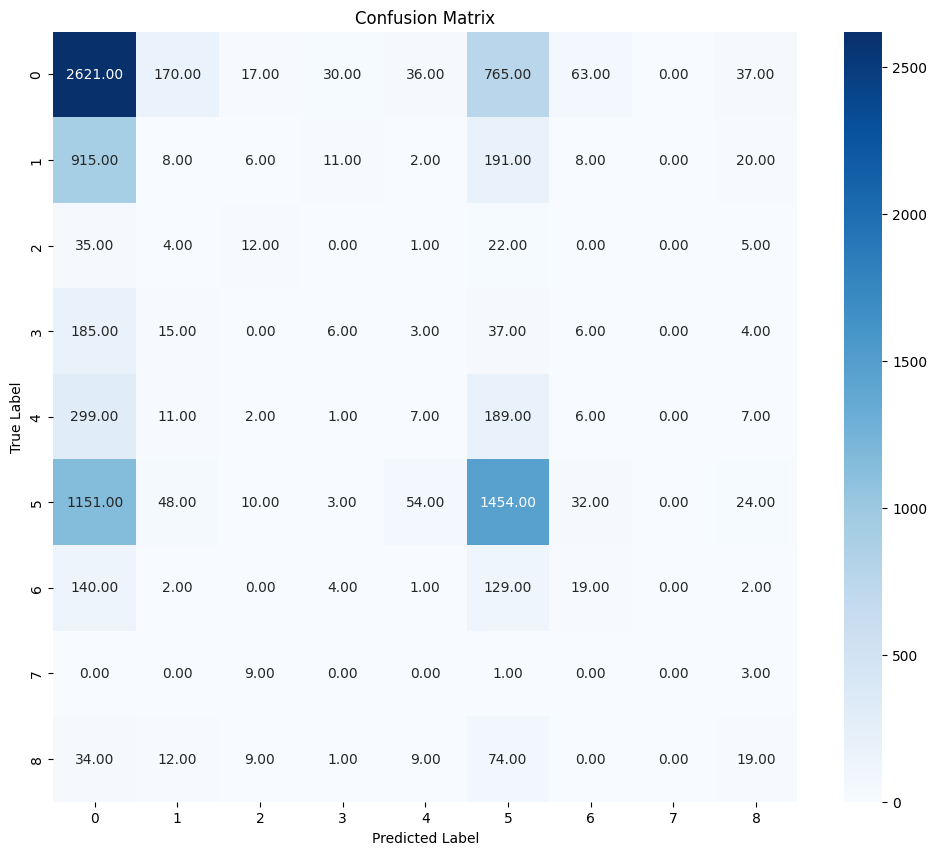

In [201]:
cnf_matrix = confusion_matrix(y_test, y_test_pred)
plt.figure(figsize=(12, 10))
sns.heatmap(cnf_matrix, annot=True, fmt='.2f', cmap='Blues')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

#### KNN

In [ ]:
knn_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('knn', KNeighborsClassifier(n_neighbors=5))
])

In [231]:
knn_pipeline.fit(X_train, y_train)
y_train_pred = knn_pipeline.predict(X_train)
y_test_pred = knn_pipeline.predict(X_test)

print(accuracy_score(y_train, y_train_pred))
print(accuracy_score(y_test, y_test_pred))
print(geometric_mean_score(y_train, y_train_pred))
print(geometric_mean_score(y_test, y_test_pred))


0.5342610338027387
0.4496167092545273
0.1839355740862508
0.0


In [232]:
X_train_prepped = preprocessor.fit_transform(X_train)
X_test_prepped = preprocessor.transform(X_test)

feature_names = preprocessor.get_feature_names_out()
knn = KNeighborsClassifier(n_neighbors=5)

sfs = SequentialFeatureSelector(knn, n_features_to_select=5, direction='forward', cv=5)
sfs.fit(X_train_prepped, y_train)

selected_indices = sfs.get_support()
selected_features = feature_names[selected_indices]

knn.fit(X_train_prepped[:, selected_indices], y_train)
result = permutation_importance(
    knn, X_test_prepped[:, selected_indices], y_test, n_repeats=10, random_state=42
)

sorted_idx = result.importances_mean.argsort()

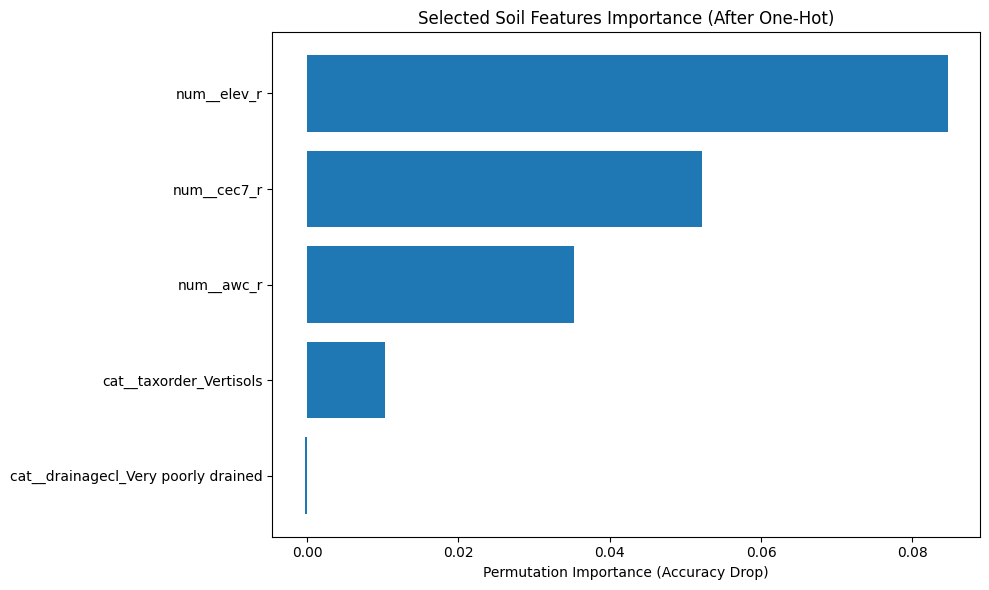

Selected features: ['num__elev_r' 'num__cec7_r' 'num__awc_r' 'cat__taxorder_Vertisols'
 'cat__drainagecl_Very poorly drained']


In [233]:
plt.figure(figsize=(10, 6))
plt.barh(selected_features[sorted_idx], result.importances_mean[sorted_idx])
plt.xlabel("Permutation Importance (Accuracy Drop)")
plt.title("Selected Soil Features Importance (After One-Hot)")
plt.tight_layout()
plt.show()

print("Selected features:", selected_features)

In [234]:
selected_features = ['elev_r', 'cec7_r', 'awc_r']
X_train_selected = X_train[selected_features]
X_test_selected = X_test[selected_features]

simple_knn_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
    ('knn', KNeighborsClassifier(n_neighbors=5)) 
])

simple_knn_pipeline.fit(X_train_selected, y_train)
y_train_pred = simple_knn_pipeline.predict(X_train_selected)
y_test_pred = simple_knn_pipeline.predict(X_test_selected)

print(f"Train Accuracy: {accuracy_score(y_train, y_train_pred):.4f}")
print(f"Test Accuracy: {accuracy_score(y_test, y_test_pred):.4f}")
print(geometric_mean_score(y_train, y_train_pred))
print(geometric_mean_score(y_test, y_test_pred))

Train Accuracy: 0.5131
Test Accuracy: 0.4594
0.0
0.0


#### Imbalanced random forest

In [220]:
imb_pipeline = ImbPipeline([
    ('preprocessor', preprocessor),
    ('oversample',  SMOTE(random_state=42)),
    ('undersample', RandomUnderSampler(random_state=42)),
    ('rf', RandomForestClassifier(class_weight='balanced'))
])

In [221]:
imb_pipeline.fit(X_train, y_train)
y_train_pred = imb_pipeline.predict(X_train)
y_test_pred = imb_pipeline.predict(X_test)

print(f"Train Accuracy: {accuracy_score(y_train, y_train_pred):.4f}")
print(f"Test Accuracy: {accuracy_score(y_test, y_test_pred):.4f}")
print(geometric_mean_score(y_train, y_train_pred))
print(geometric_mean_score(y_test, y_test_pred))

Train Accuracy: 0.4791
Test Accuracy: 0.3405
0.5140835809310703
0.31325636357225634


In [ ]:
print(y_test)
print(y_test_pred)

AttributeError: 'Series' object has no attribute 'columns'

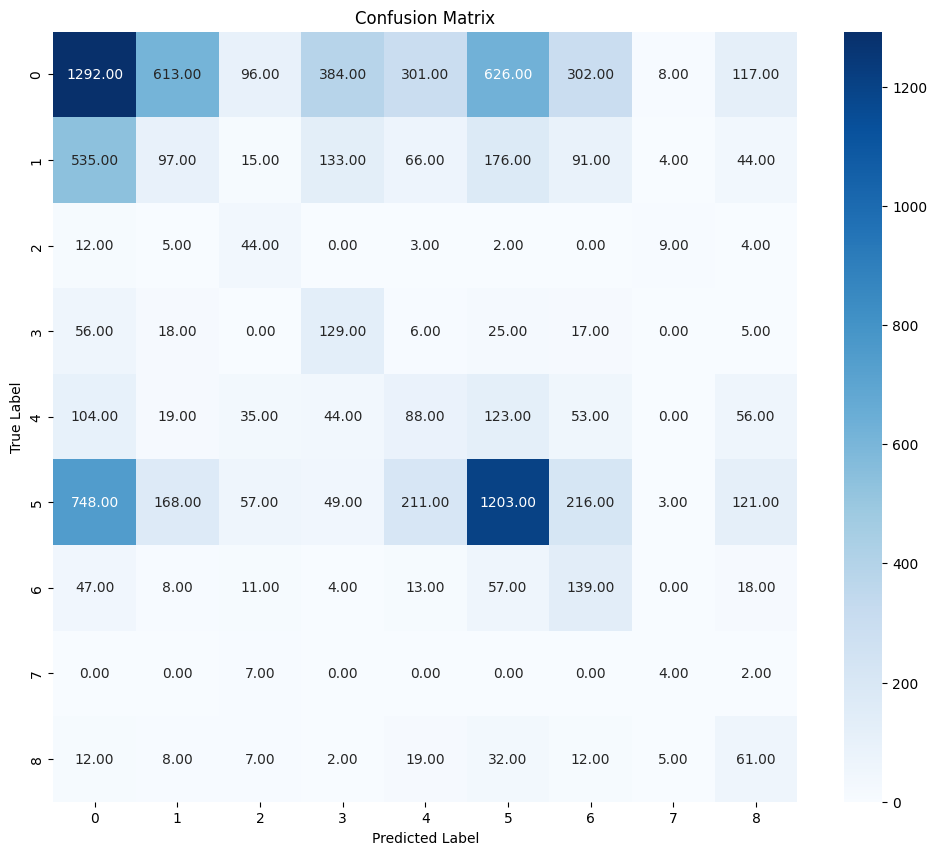

In [212]:
cnf_matrix = confusion_matrix(y_test, y_test_pred)
plt.figure(figsize=(12, 10))
sns.heatmap(cnf_matrix, annot=True, fmt='.2f', cmap='Blues')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()